In [2]:
!pip install numpy matplotlib seaborn scikit-learn

# Cell 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Number of samples: 3023
Number of features: 11750
Image shape: (125, 94)


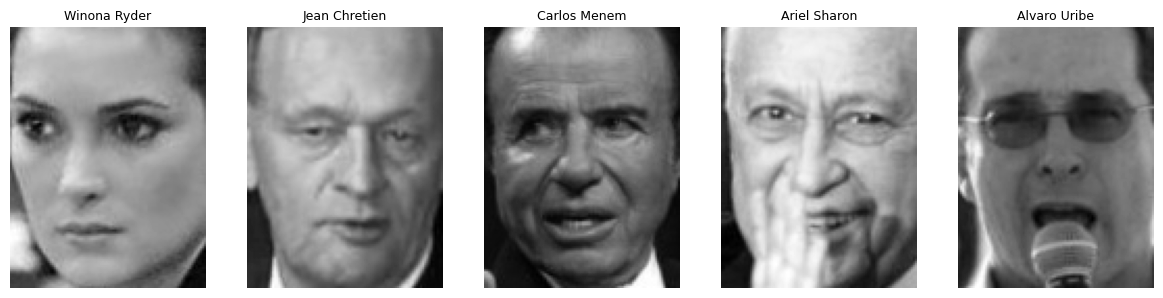

In [4]:

# Cell 2: Load dataset and show info
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(min_faces_per_person=20, resize=1)

X = lfw.data
y = lfw.target
images = lfw.images

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Image shape:", images[0].shape)

# Show 5 sample images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap="gray")
    title = lfw.target_names[y[i]] if hasattr(lfw, "target_names") else f"label={y[i]}"
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()




In [5]:
#Cell 3 : change scale
image_shape = images[0].shape
n_samples, n_features = X.shape

X_float = X.astype(np.float32) / 255.0

scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X_float)
print(X_scaled[0])

[-0.5052576  -0.43021426 -0.43992344 ... -1.2039436  -1.1197315
 -1.0187144 ]


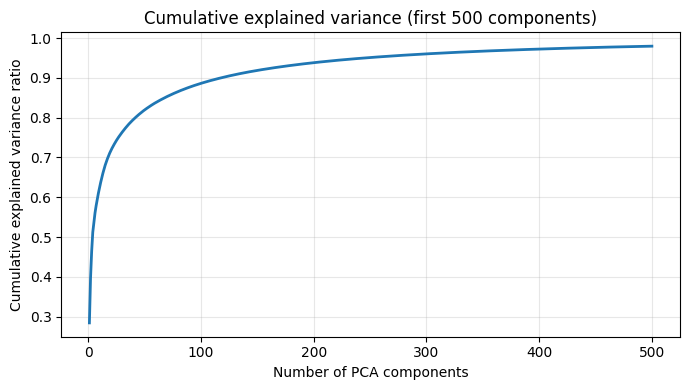

X shape: (3023, 11750)
Image shape: (125, 94)
Cumulative explained variance @ 15:  0.6807
Cumulative explained variance @ 20:  0.7171
Cumulative explained variance @ 50:  0.8196
Cumulative explained variance @ 150: 0.9188
Cumulative explained variance @ 250: 0.9512
Cumulative explained variance @ 500: 0.9797
PCA models created for dims: [15, 20, 50, 150, 250, 500]


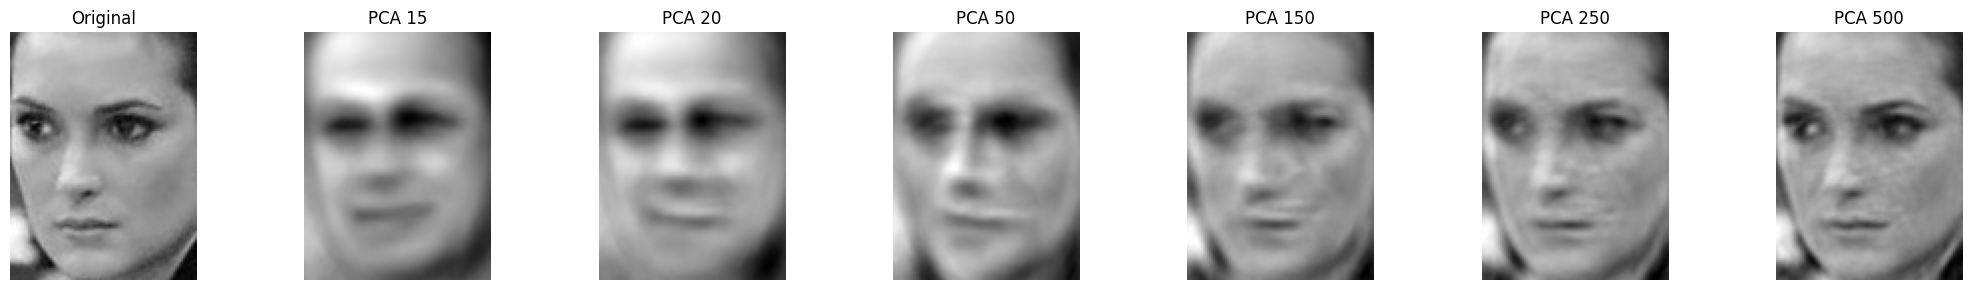

In [ ]:
#Cell 4 implement PCA with diffrent dimensions

RANDOM_STATE = 42



# Fit PCA up to 500 components for variance diagnostics and for clustering later
PCA_MAX = 500
pca_500 = PCA(n_components=PCA_MAX, random_state=RANDOM_STATE)
pca_500.fit(X_scaled)

cum_var = np.cumsum(pca_500.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, PCA_MAX + 1), cum_var, linewidth=2)
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance ratio")
plt.title(f"Cumulative explained variance (first {PCA_MAX} components)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"X shape: {X.shape}")
print(f"Image shape: {image_shape}")
print(f"Cumulative explained variance @ 15:  {cum_var[14]:.4f}")
print(f"Cumulative explained variance @ 20:  {cum_var[19]:.4f}")
print(f"Cumulative explained variance @ 50:  {cum_var[49]:.4f}")
print(f"Cumulative explained variance @ 150: {cum_var[149]:.4f}")
print(f"Cumulative explained variance @ 250: {cum_var[249]:.4f}")
print(f"Cumulative explained variance @ 500: {cum_var[499]:.4f}")

# Build PCA models that you will reuse for KMeans and EM(GMM)
PCA_DIMS_ALL = [15, 20, 50, 150, 250, 500]
pca_models = {}
X_pca_dict = {}

for d in PCA_DIMS_ALL:
    pca = PCA(n_components=d, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    pca_models[d] = pca
    X_pca_dict[d] = X_pca

print("PCA models created for dims:", PCA_DIMS_ALL)

# Show one sample image reconstructed with PCA dims 15, 20, 50
idx = 0
dims_to_show = [15, 20, 50, 150, 250, 500]

orig_img = X_float[idx].reshape(image_shape)

fig, axes = plt.subplots(1, 1 + len(dims_to_show), figsize=(3 * (1 + len(dims_to_show)), 3))

# Original
axes[0].imshow(orig_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

# Reconstructions
for i, d in enumerate(dims_to_show, start=1):
    pca = pca_models[d]
    z = pca.transform(X_scaled[idx:idx+1])
    recon_scaled = pca.inverse_transform(z)
    recon_float = scaler.inverse_transform(recon_scaled)
    recon_img = np.clip(recon_float.reshape(image_shape), 0.0, 1.0)

    axes[i].imshow(recon_img, cmap="gray")
    axes[i].set_title(f"PCA {d}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

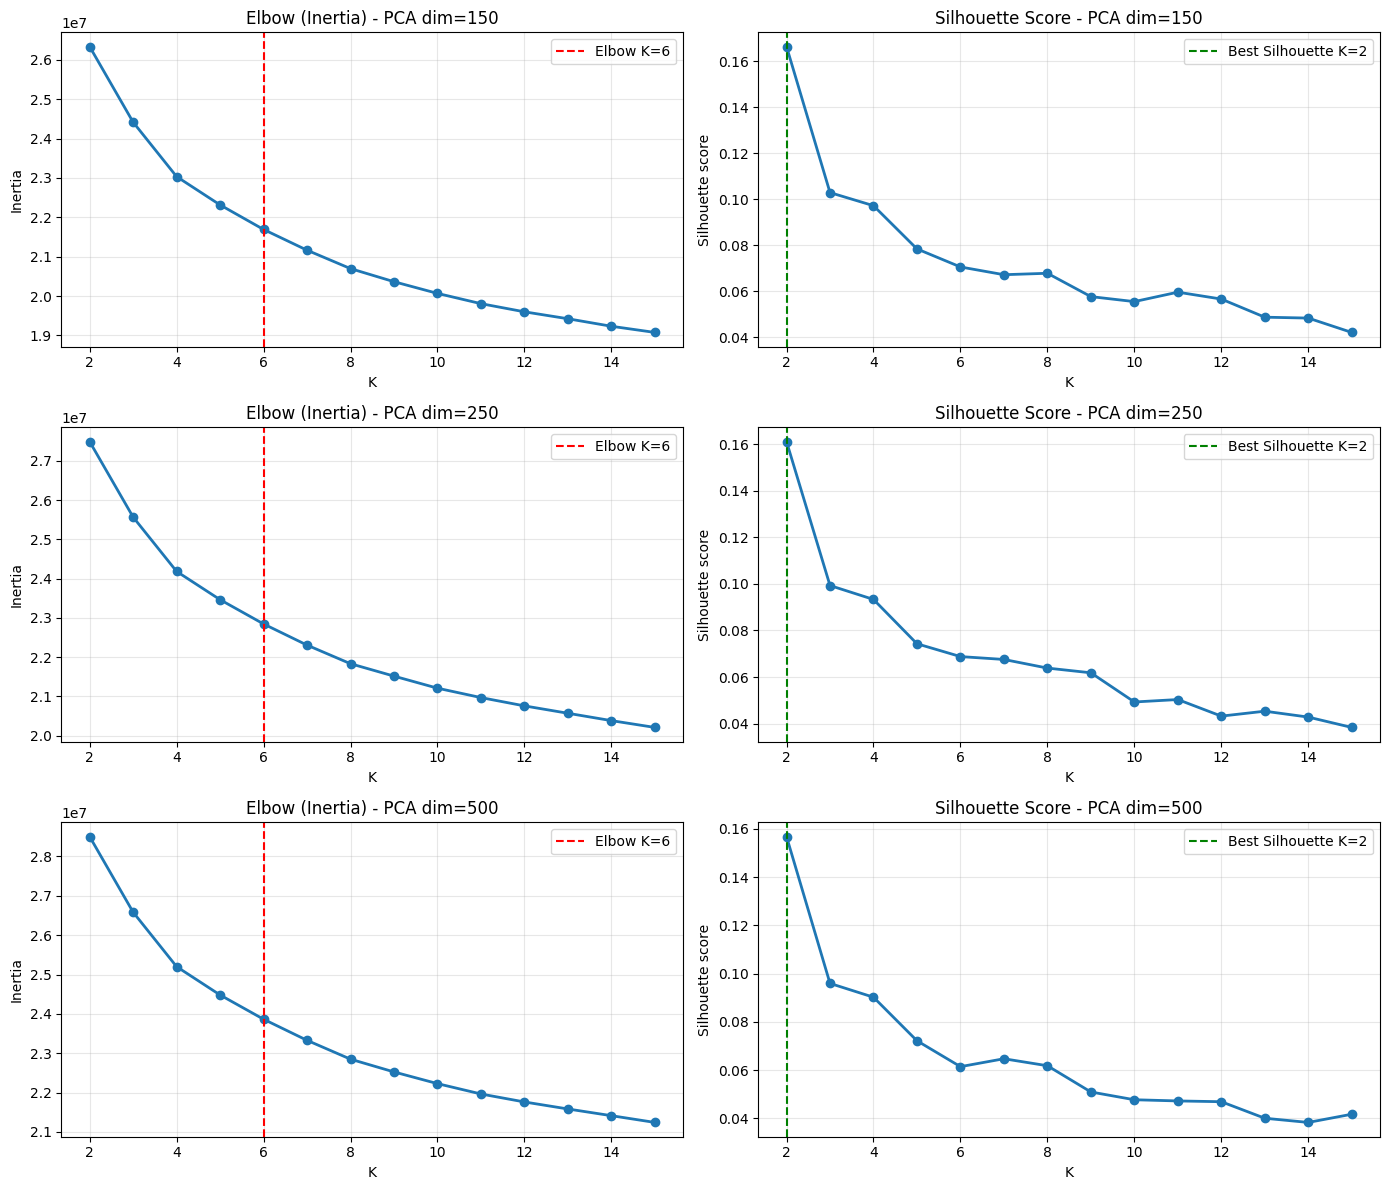

K selection summary (based on Elbow/Inertia and Silhouette):
PCA dim=150 | Elbow K=6 | Best Silhouette K=2 (score=0.1664)
PCA dim=250 | Elbow K=6 | Best Silhouette K=2 (score=0.1611)
PCA dim=500 | Elbow K=6 | Best Silhouette K=2 (score=0.1568)


In [21]:
# Cell 5: K-Means clustering on PCA-reduced data (dims: 150, 250, 500)
# Goal: Use Elbow (Inertia) and Silhouette Score to help select a suitable K.


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Assumes these already exist from the PCA cell:
# - RANDOM_STATE
# - X_pca_dict with keys {150, 250, 500}
# Example: X_pca_dict[150].shape == (n_samples, 150)

PCA_DIMS = [150, 250, 500]
K_VALUES = list(range(2, 16))  # Typical search range; adjust if needed.

def elbow_k_by_max_distance(k_values, inertias):
    """
    Simple elbow detection: pick the point with maximum perpendicular distance
    to the line connecting the first and last points (normalized coordinates).
    """
    x = np.array(k_values, dtype=float)
    y = np.array(inertias, dtype=float)

    # Normalize to [0, 1] for numerical stability
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

    # Line from first to last point in normalized space
    p1 = np.array([x_n[0], y_n[0]])
    p2 = np.array([x_n[-1], y_n[-1]])
    v = p2 - p1
    v_norm = np.linalg.norm(v) + 1e-12

    # Perpendicular distances from each point to the line
    distances = []
    for xi, yi in zip(x_n, y_n):
        p = np.array([xi, yi])
        dist = np.abs(np.cross(v, p - p1)) / v_norm
        distances.append(dist)

    distances = np.array(distances)
    return int(k_values[int(np.argmax(distances))])

results = {}

for d in PCA_DIMS:
    Xr = X_pca_dict[d]

    inertias = []
    silhouettes = []

    for k in K_VALUES:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(Xr)

        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(Xr, labels))

    elbow_k = elbow_k_by_max_distance(K_VALUES, inertias)
    best_sil_k = int(K_VALUES[int(np.argmax(silhouettes))])
    best_sil = float(np.max(silhouettes))

    results[d] = {
        "k_values": K_VALUES,
        "inertia": inertias,
        "silhouette": silhouettes,
        "elbow_k": elbow_k,
        "best_sil_k": best_sil_k,
        "best_sil": best_sil,
    }

# Plot Elbow (Inertia) and Silhouette for each PCA dimension
fig, axes = plt.subplots(len(PCA_DIMS), 2, figsize=(14, 4 * len(PCA_DIMS)), sharex=False)

if len(PCA_DIMS) == 1:
    axes = np.array([axes])

for i, d in enumerate(PCA_DIMS):
    k_vals = results[d]["k_values"]
    inertias = results[d]["inertia"]
    sils = results[d]["silhouette"]
    elbow_k = results[d]["elbow_k"]
    best_sil_k = results[d]["best_sil_k"]

    # Elbow plot
    ax = axes[i, 0]
    ax.plot(k_vals, inertias, marker="o", linewidth=2)
    ax.axvline(elbow_k, color="red", linestyle="--", linewidth=1.5, label=f"Elbow K={elbow_k}")
    ax.set_title(f"Elbow (Inertia) - PCA dim={d}")
    ax.set_xlabel("K")
    ax.set_ylabel("Inertia")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Silhouette plot
    ax = axes[i, 1]
    ax.plot(k_vals, sils, marker="o", linewidth=2)
    ax.axvline(best_sil_k, color="green", linestyle="--", linewidth=1.5, label=f"Best Silhouette K={best_sil_k}")
    ax.set_title(f"Silhouette Score - PCA dim={d}")
    ax.set_xlabel("K")
    ax.set_ylabel("Silhouette score")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Summary printout
print("K selection summary (based on Elbow/Inertia and Silhouette):")
for d in PCA_DIMS:
    print(
        f"PCA dim={d} | "
        f"Elbow K={results[d]['elbow_k']} | "
        f"Best Silhouette K={results[d]['best_sil_k']} (score={results[d]['best_sil']:.4f})"
    )

In [ ]:
RANDOM_STATE = 42

def mse(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return float(np.mean((a - b) ** 2))

rows = []

for pca_dim in PCA_DIMS:
    pca = pca_models[pca_dim]
    X_pca = X_pca_dict[pca_dim]
    n = X_pca.shape[0]

    for k in K_LIST:
        # KMeans
        km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
        labels_km = km.fit_predict(X_pca)

        centers_scaled = pca.inverse_transform(km.cluster_centers_)
        centers_float = scaler.inverse_transform(centers_scaled)
        X_recon_km = centers_float[labels_km]
        km_recon_mse = mse(X_float, X_recon_km)

        km_sil = silhouette_score(X_pca, labels_km)

        rows.append({
            "pca_dim": pca_dim,
            "k": k,
            "method": "KMeans",
            "recon_mse": km_recon_mse,
            "silhouette": float(km_sil),
            "loglik_avg": np.nan,
            "loglik_total": np.nan,
            "bic": np.nan,
            "aic": np.nan,
            "inertia": float(km.inertia_)
        })

        # EM via GMM
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            n_init=3,
            reg_covar=1e-6,
            random_state=RANDOM_STATE
        )
        gmm.fit(X_pca)
        labels_em = gmm.predict(X_pca)

        ll_avg = float(gmm.score(X_pca))      # per-sample average log-likelihood
        ll_total = float(ll_avg * n)

        R = gmm.predict_proba(X_pca)          # responsibilities (n, k)
        X_recon_pca = R @ gmm.means_          # (n, pca_dim)
        X_recon_scaled = pca.inverse_transform(X_recon_pca)
        X_recon_float = scaler.inverse_transform(X_recon_scaled)
        em_recon_mse = mse(X_float, X_recon_float)

        em_sil = silhouette_score(X_pca, labels_em)

        rows.append({
            "pca_dim": pca_dim,
            "k": k,
            "method": "EM(GMM)",
            "recon_mse": em_recon_mse,
            "silhouette": float(em_sil),
            "loglik_avg": ll_avg,
            "loglik_total": ll_total,
            "bic": float(gmm.bic(X_pca)),
            "aic": float(gmm.aic(X_pca)),
            "inertia": np.nan
        })

results = pd.DataFrame(rows)

def pick_best(df, primary, primary_asc, secondary, secondary_asc):
    return (df.sort_values([primary, secondary], ascending=[primary_asc, secondary_asc])
              .iloc[0])

summary_rows = []
decision_rows = []

for pca_dim in PCA_DIMS_CLUSTER:
    df_dim = results[results["pca_dim"] == pca_dim]
    df_km = df_dim[df_dim["method"] == "KMeans"].copy()
    df_em = df_dim[df_dim["method"] == "EM(GMM)"].copy()

    best_km = pick_best(df_km, primary="recon_mse", primary_asc=True,
                        secondary="silhouette", secondary_asc=False)
    best_em = pick_best(df_em, primary="recon_mse", primary_asc=True,
                        secondary="silhouette", secondary_asc=False)

    best_em_ll = df_em.sort_values("loglik_total", ascending=False).iloc[0]
    best_em_bic = df_em.sort_values("bic", ascending=True).iloc[0]

    summary_rows.append({
        "pca_dim": int(pca_dim),

        "best_km_k": int(best_km["k"]),
        "best_km_recon_mse": float(best_km["recon_mse"]),
        "best_km_silhouette": float(best_km["silhouette"]),

        "best_em_k_by_mse": int(best_em["k"]),
        "best_em_recon_mse": float(best_em["recon_mse"]),
        "best_em_silhouette": float(best_em["silhouette"]),

        "best_em_k_by_ll": int(best_em_ll["k"]),
        "best_em_loglik_total": float(best_em_ll["loglik_total"]),

        "best_em_k_by_bic": int(best_em_bic["k"]),
        "best_em_bic": float(best_em_bic["bic"]),
    })

    km_mse = float(best_km["recon_mse"])
    em_mse = float(best_em["recon_mse"])
    km_sil = float(best_km["silhouette"])
    em_sil = float(best_em["silhouette"])

    if em_mse < km_mse:
        winner = "EM(GMM)"
        rationale = "lower reconstruction MSE"
    elif km_mse < em_mse:
        winner = "KMeans"
        rationale = "lower reconstruction MSE"
    else:
        winner = "EM(GMM)" if em_sil >= km_sil else "KMeans"
        rationale = "tie on reconstruction MSE; higher silhouette used"

    decision_rows.append({
        "pca_dim": int(pca_dim),
        "winner": winner,
        "rationale": rationale,
        "kmeans_best_k": int(best_km["k"]),
        "kmeans_recon_mse": km_mse,
        "kmeans_silhouette": km_sil,
        "em_best_k": int(best_em["k"]),
        "em_recon_mse": em_mse,
        "em_silhouette": em_sil,
        "em_bic_at_best": float(best_em_bic["bic"]),
    })

summary = pd.DataFrame(summary_rows)
decision = pd.DataFrame(decision_rows)

print("=== Summary (best configurations per PCA dimension) ===")
print(summary.to_string(index=False))

print("\n=== Decision (based on reconstruction MSE, then silhouette) ===")
print(decision.to_string(index=False))

print("\n=== Full results (first 20 rows) ===")
print(results.head(20).to_string(index=False))

C:\Reza\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:270: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


=== Summary (best configurations per PCA dimension) ===
 pca_dim  best_km_k  best_km_recon_mse  best_km_silhouette  best_em_k_by_mse  best_em_recon_mse  best_em_silhouette  best_em_k_by_ll  best_em_loglik_total  best_em_k_by_bic  best_em_bic
     150         10       2.713584e-07            0.056681                10       2.741982e-07            0.049975               10         -1.230318e+06                 2 2.776697e+06
     250         10       2.727771e-07            0.048340                10       2.727744e-07            0.048396               10         -1.529259e+06                 2 4.351272e+06
     500         10       2.708895e-07            0.051856                10       2.708895e-07            0.051856               10          1.210712e+06                10 7.656259e+06

=== Decision (based on reconstruction MSE, then silhouette) ===
 pca_dim  winner                                         rationale  kmeans_best_k  kmeans_recon_mse  kmeans_silhouette  em_best_k  em_r

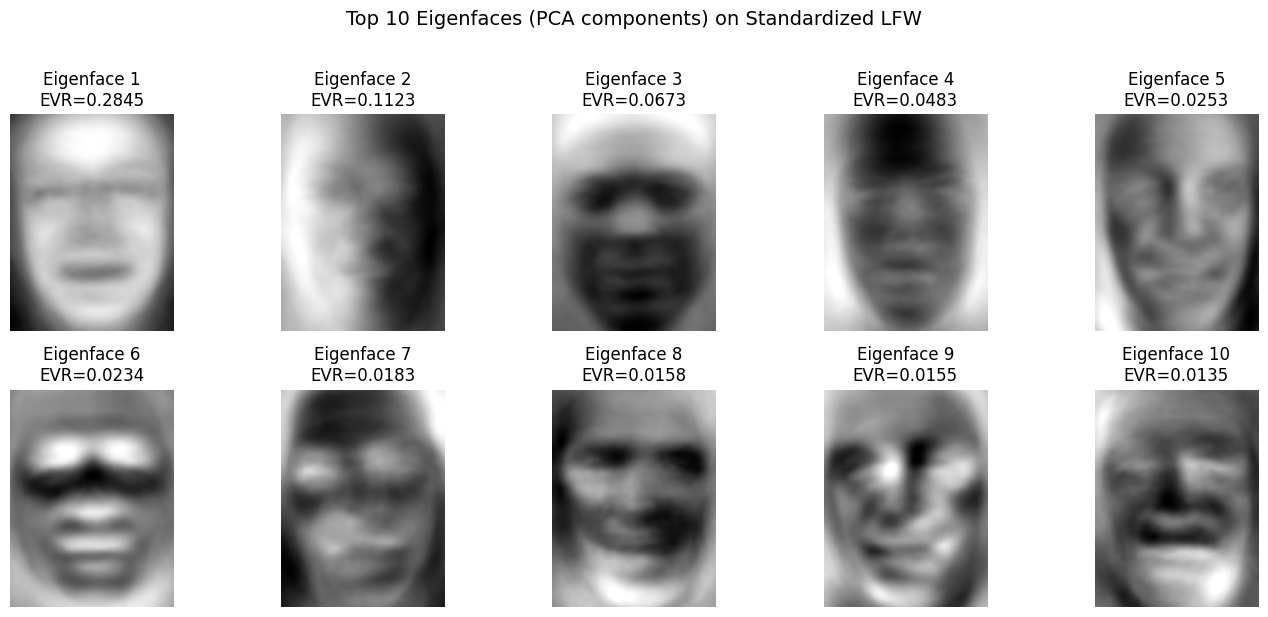

Top 10 explained variance ratios (EVR):
   1: EVR=0.284473   explained_var=3343.663574
   2: EVR=0.112287   explained_var=1319.809570
   3: EVR=0.067274   explained_var=790.735535
   4: EVR=0.048324   explained_var=567.992615
   5: EVR=0.025331   explained_var=297.736176
   6: EVR=0.023425   explained_var=275.333801
   7: EVR=0.018255   explained_var=214.564255
   8: EVR=0.015808   explained_var=185.807999
   9: EVR=0.015518   explained_var=182.400070
  10: EVR=0.013502   explained_var=158.704910


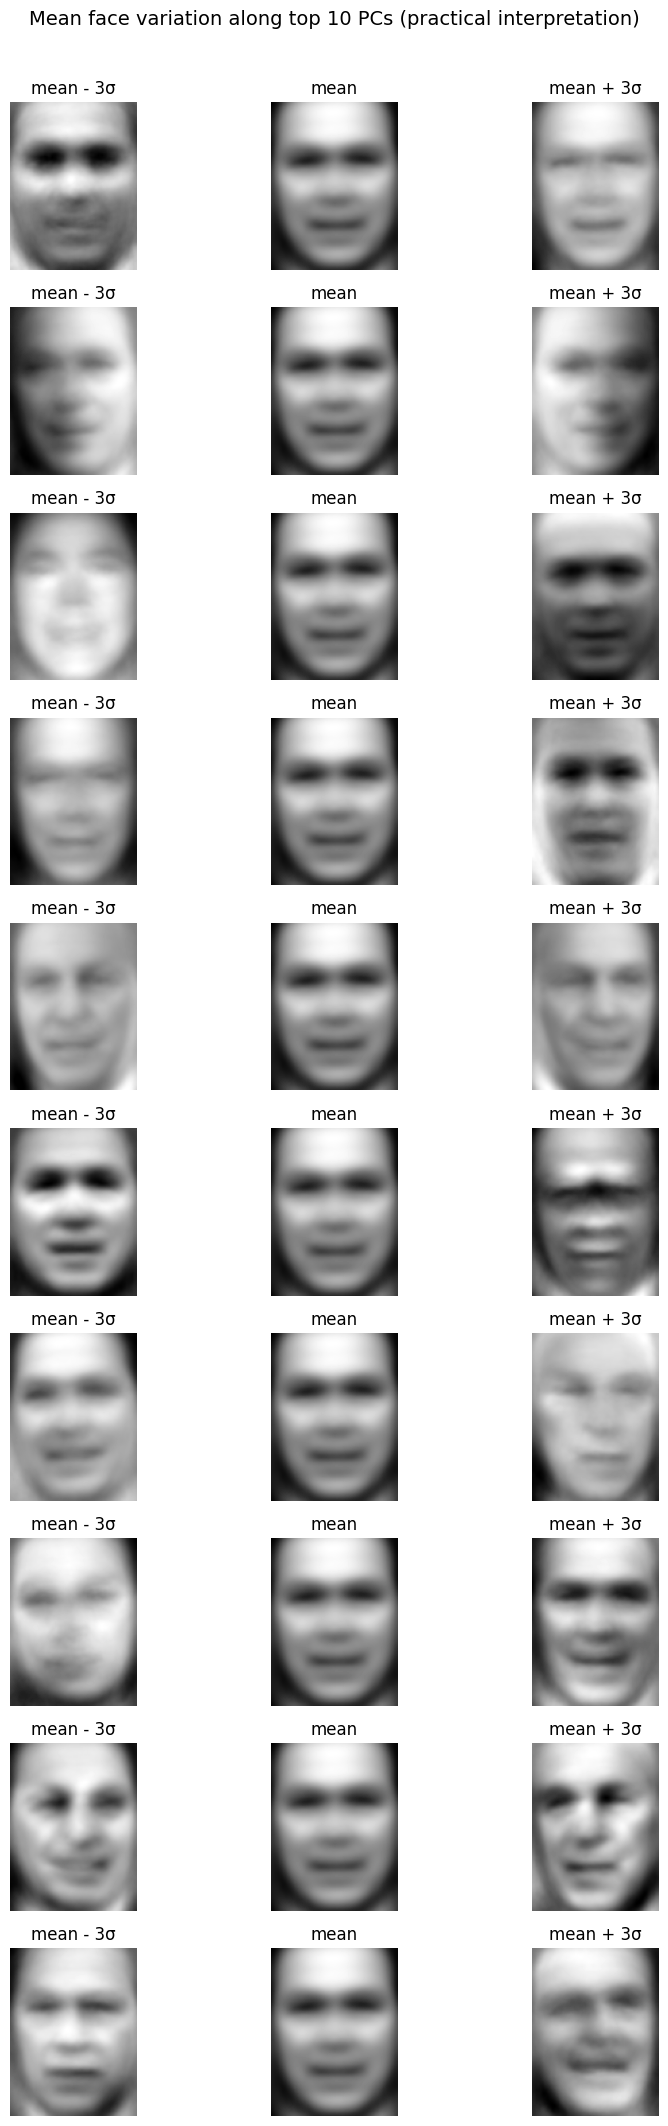

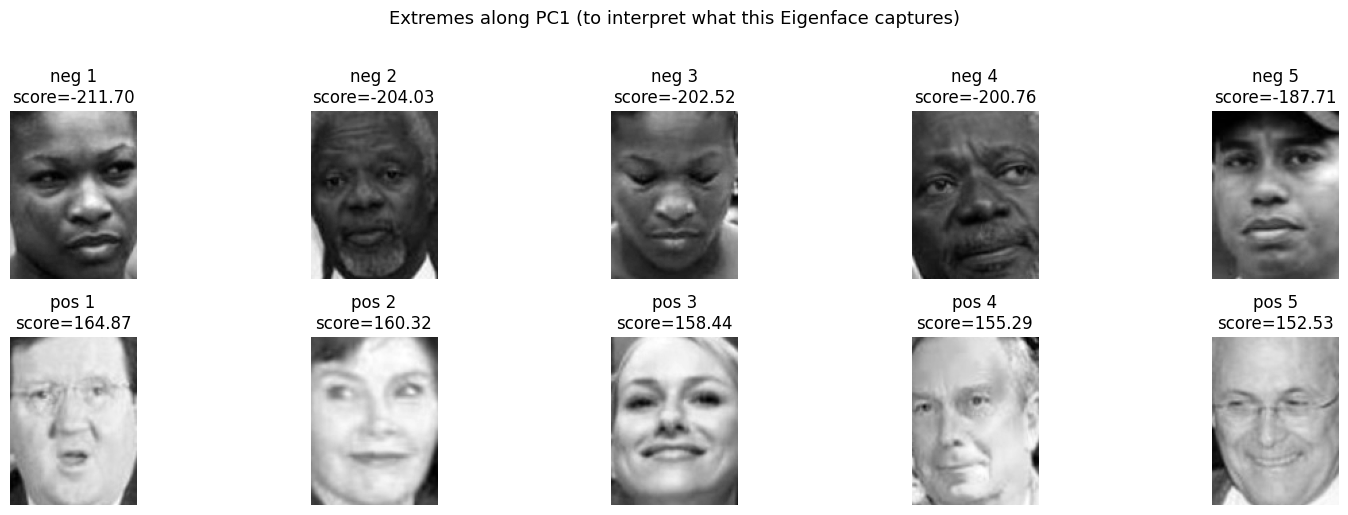

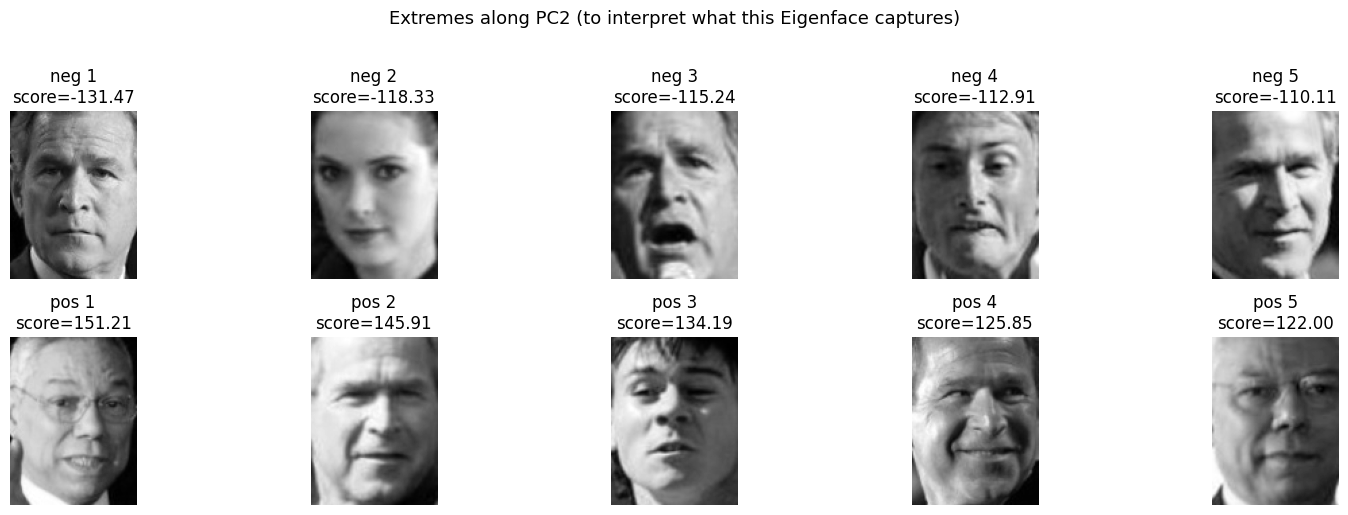

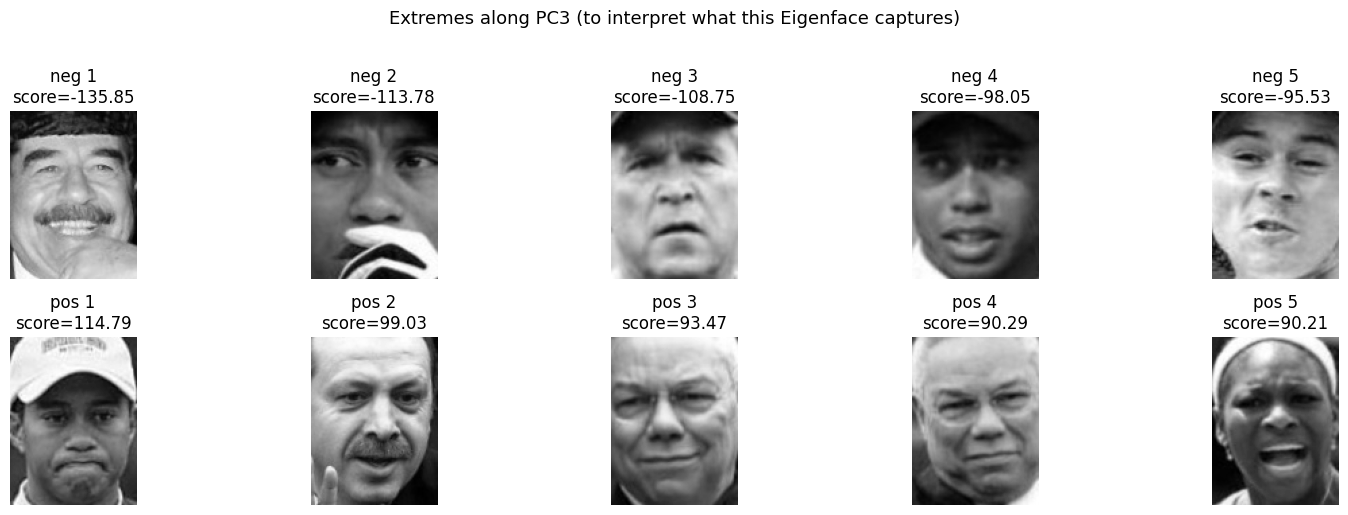

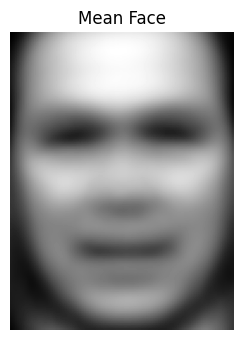

In [25]:
# New Cell: Step 6 — Plot and interpret Eigenfaces (PCA Components)
# Assumes these are already defined from previous cells:
# pca_500, X_scaled, X_float, image_shape, scaler

import numpy as np
import matplotlib.pyplot as plt

pca_vis = pca_500  # PCA already fit on standardized data

# -------------------------------------------------------
# (a) Plot the first 10 Eigenfaces (top PCA components)
# -------------------------------------------------------
n_show = 10
components = pca_vis.components_[:n_show]                # (10, n_features)
evr = pca_vis.explained_variance_ratio_[:n_show]         # variance ratio per component
ev = pca_vis.explained_variance_[:n_show]                # explained variance per component

# Mean face in the original pixel space (useful for interpretation)
mean_scaled = pca_vis.mean_.reshape(1, -1)
mean_face = scaler.inverse_transform(mean_scaled).reshape(image_shape)
mean_face = np.clip(mean_face, 0.0, 1.0)

def eigenface_to_display(comp2d, pct=99.5):
    """
    Eigenfaces contain positive/negative values.
    For visualization: do a symmetric normalization then map to [0, 1].
    """
    s = np.percentile(np.abs(comp2d), pct)
    if s < 1e-12:
        s = np.max(np.abs(comp2d)) + 1e-12
    x = np.clip(comp2d / s, -1.0, 1.0)
    x = (x + 1.0) / 2.0
    return x

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.ravel()
for i in range(n_show):
    ef = components[i].reshape(image_shape)
    axes[i].imshow(eigenface_to_display(ef), cmap="gray")
    axes[i].set_title(f"Eigenface {i+1}\nEVR={evr[i]:.4f}")
    axes[i].axis("off")

plt.suptitle("Top 10 Eigenfaces (PCA components) on Standardized LFW", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print("Top 10 explained variance ratios (EVR):")
for i in range(n_show):
    print(f"  {i+1:2d}: EVR={evr[i]:.6f}   explained_var={ev[i]:.6f}")

# -------------------------------------------------------
# (b) Practical meaning: visualize mean +/- 3σ along each PC
# This shows what kind of changes each component tends to encode.
# -------------------------------------------------------
fig, axes = plt.subplots(n_show, 3, figsize=(9, 2.1 * n_show))

for i in range(n_show):
    # Std of scores along PC_i is sqrt(explained_variance_i)
    t = 3.0 * np.sqrt(ev[i])

    for j, sgn in enumerate([-1.0, 0.0, +1.0]):
        x_scaled = mean_scaled + (sgn * t) * components[i].reshape(1, -1)
        x_float = scaler.inverse_transform(x_scaled).reshape(image_shape)
        x_float = np.clip(x_float, 0.0, 1.0)

        axes[i, j].imshow(x_float, cmap="gray")
        if j == 0:
            axes[i, j].set_ylabel(f"PC{i+1}", rotation=0, labelpad=25, va="center")
        axes[i, j].set_title(["mean - 3σ", "mean", "mean + 3σ"][j])
        axes[i, j].axis("off")

plt.suptitle("Mean face variation along top 10 PCs (practical interpretation)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# Optional helper: show extreme examples (most negative/positive) for first few PCs
pcs_to_inspect = 3
n_extremes = 5

Z = pca_vis.transform(X_scaled)  # PC scores for all samples

for pc in range(pcs_to_inspect):
    scores = Z[:, pc]
    neg_idx = np.argsort(scores)[:n_extremes]
    pos_idx = np.argsort(scores)[-n_extremes:][::-1]

    fig, axes = plt.subplots(2, n_extremes, figsize=(3.2 * n_extremes, 5))
    for j, idx in enumerate(neg_idx):
        img = X_float[idx].reshape(image_shape)
        axes[0, j].imshow(img, cmap="gray")
        axes[0, j].set_title(f"neg {j+1}\nscore={scores[idx]:.2f}")
        axes[0, j].axis("off")

    for j, idx in enumerate(pos_idx):
        img = X_float[idx].reshape(image_shape)
        axes[1, j].imshow(img, cmap="gray")
        axes[1, j].set_title(f"pos {j+1}\nscore={scores[idx]:.2f}")
        axes[1, j].axis("off")

    plt.suptitle(f"Extremes along PC{pc+1} (to interpret what this Eigenface captures)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

# Mean face (optional)
plt.figure(figsize=(3.5, 3.5))
plt.imshow(mean_face, cmap="gray")
plt.title("Mean Face")
plt.axis("off")
plt.tight_layout()
plt.show()